In [ ]:
from fastcore.all import *
from iomeval.readers import find_eval, load_evals, eval_url, get_report_urls
from mistocr.core import read_pgs
from pathlib import Path

import pandas as pd
from iomeval.pipeline import run_pipeline, batch_run

pd.set_option('display.max_colwidth', None)

In [ ]:
models = [
    'claude-sonnet-4-5',
    'claude-sonnet-4-6', 
    'claude-opus-4-5-20251101'
    ]

In [ ]:
#DATA_PATH = Path('../../data')

In [ ]:
DATA_PATH = Path().home() / 'iomeval/data'

In [ ]:
EVALS_PATH = Path().home() / 'iomeval/nbs/files/test/evaluations.json'

In [ ]:
evals = load_evals(EVALS_PATH)

In [ ]:
len((DATA_PATH / 'results').ls())

570

In [ ]:
rpt = (DATA_PATH / 'results').ls()[0]
rpt

Path('/app/data/iomeval/data/results/bf162f9ddcf7f69f64ab4933054e57c5.json')

In [ ]:
def is_mapped(o): return bool(o.read_json().get('mappings'))
def is_ready(o): return o.read_json().get('curation_status') == 'sections_selected'
def get_rpts(rpts_path, filt=None):
    rpts = rpts_path.ls()
    if filt: rpts = L(o for o in rpts if filt(o))
    return rpts.sorted(key=lambda x: x.read_json()['meta'].get('Date of Publication', ''), reverse=True)

In [ ]:
path = DATA_PATH / 'results'

In [ ]:
# reports already tagged
len(get_rpts(path, is_mapped))

526

In [ ]:
# reports not yet tagged
len(get_rpts(path, lambda o: not is_mapped(o)))

44

In [ ]:
# ready to be tagged
len(get_rpts(path, lambda o: not is_mapped(o) and is_ready(o)))

4

In [ ]:
# tagged but also ready (for re-tagging?)
len(get_rpts(path, lambda o: is_mapped(o) and is_ready(o)))

526

In [ ]:
def load_result(eval_id, base_path):
    "Load a result JSON by eval_id from base_path"
    return (Path(base_path)/f'{eval_id}.json').read_json()


In [ ]:
#rpt.read_json()

In [ ]:
TAGAPP_DATA = Path('../../../tagapp/tagapp/data')

In [ ]:
# Research reports to exclude
to_exclude = [str(i) + '1'*31 for i in range(1,6)]

rpts = TAGAPP_DATA.ls(file_exts='.json').filter(lambda o: o.stem not in to_exclude)

In [ ]:
rpts[0].read_json()

{'id': 'bf162f9ddcf7f69f64ab4933054e57c5',
 'report_url': 'https://evaluation.iom.int/sites/g/files/tmzbdl151/files/docs/resources/Informe%2520Ex%2520Post%2520Evaluaci%25C3%25B3n%2520NTMI%252022-2-2019.pdf',
 'meta': {'Title': 'EVALUACIÓN EX POST DEL PROYECTO INICIATIVA DE GESTIÓN DE INFORMACIÓN DE MOVILIDAD HUMANA EN EL TRIÁNGULO NORTE - NTMI',
  'Year': 2018,
  'Author': 'Consultoría para el desarrollo económico social y negocias (CEDES)',
  'Best Practicesor Lessons Learnt': 'Yes',
  'Date of Publication': '2018-10-17',
  'Donor': 'Government of the United States',
  'Evaluation Brief': 'Yes',
  'Evaluation Commissioner': 'IOM',
  'Evaluation Coverage': 'Regional',
  'Evaluation Period From Date': '2015-09-30',
  'Evaluation Period To Date': '2018-03-31',
  'Executive Summary': 'No',
  'External Version of the Report': 'No',
  'Languages': 'Spanish',
  'Migration Thematic Areas': 'Preparedness and Response - Displacement Tracking matrix',
  'Name of Project(s) Being Evaluated': nan,

## Export to PowerBI, ObservableHQ, ...

I wanna export the tagged reports as shown below for data vis. and analysis tools. Can we brainstorm a bit about the ideal format? Some ideas to scope our chat:
1. we are interested in metadata such as

```
report_url
the Title
Year
Author
Donor
Languages
Number of Pages Excluding annexes
Project Code
Countries Covered
Regions Covered
Type of Evaluation Scope
Type of Evaluation Timing
Type of Evaluator
Level of Evaluation
```
per report
2. the tags for gcm objectives (GCMS), SRF enablers (ENBS), SRF Cross-Cutting Priorities (CCPS), SRF Outputs (OUTS)... along with their "relevance_score" and "theme_id"
3. Wel aso want to add per tag to add a class like 

```
def rel_class(score):
    "Classify a GCM relevance score"
    if score >= 0.84: return 'Fundamental'
    if score >= 0.66: return 'Relevant'
    if score >= 0.34: return 'Peripheral'
    if score >= 0.34: return 'Peripheral'
    return 'Relevant'
```

4. Last I think the best way would be to structure it in a tidy dataset (refer to H. Wickham rationale about that). The only issue is that we will repeat a lot the metadata we wanna keep per report. So maybe we could just use the id and have another file as lookup table to retrieve the metadata? What do you think?


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

I think a single flat table is actually the most practical here — and more aligned with Wickham's tidy data than you might expect.

Here's my reasoning:

**Tidy data principle**: each observation is one row. The question is just: what's "an observation"? 

- If a report has tags for 30 GCM objectives, you get 30 rows — one per tag per report. That *is* tidy. The metadata repeats, but that's expected and fine. It's the classic star-schema fact table.
- PowerBI and Observable both handle this well. PowerBI can still use the report-level metadata as a dimension if you want, but you don't have to — it'll work great as a single flat import.

The repetition is not really a problem in practice — CSVs compress well, and 570 reports × ~100 tags each = ~57k rows, which is tiny.

Also, spotted a bug in your `rel_class` — two conditions for `>= 0.34` with different returns, so the `'Relevant'` line is unreachable. The thresholds you likely meant:

```python
def rel_class(score):
    "Classify a GCM relevance score"
    if score >= 0.84: return 'Fundamental'
    if score >= 0.66: return 'Relevant'
    if score >= 0.34: return 'Peripheral'
    return 'Irrelevant'
```

**My recommendation**: export a single tidy CSV with columns for the metadata fields you listed plus `tag_type`, `tag_id`, `theme_title`, `relevance_score`, `relevance_class`, `reasoning`. One row per tag per report. Simple, importable everywhere, no joins needed.

Want me to start building the export?

<details class='token-usage-details' markdown='1'><summary>$0.0004</summary>

`total=22,281 | in=21,526 | out=755 | cached=98.1% | reasoning=387 | searches=0 | $0.0004`

</details>


But the issues might be the following, for each report we have the same nb of tags for GCMS, ENBS, CCPS but it varies for OUTS

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

That's actually perfect for tidy data — varying row counts per report is standard, not a problem. A report with 23 GCM + 7 ENBS + 4 CCPS + say 8 OUTS = 42 rows. Another with 6 OUTS gives 40 rows. Different totals, same structure — that's exactly what Wickham's design handles naturally.

No need to pad or normalize. The tidy format is already the right shape for this.

Want me to write the export code so you can test it on a couple of reports?

<details class='token-usage-details' markdown='1'><summary>$0.0015</summary>

`total=22,229 | in=21,982 | out=247 | cached=69.3% | reasoning=134 | searches=0 | $0.0015`

</details>


And we will have multiple rows per report right? Can you show me an example?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Sure — let me grab a couple of reports and show you the tidy shape with actual data:

```python
def rel_class(score):
    "Classify a GCM relevance score"
    if score >= 0.84: return 'Fundamental'
    if score >= 0.66: return 'Relevant'
    if score >= 0.34: return 'Peripheral'
    return 'Irrelevant'

fields = ['report_url','Title','Year','Author','Donor','Languages',
    'Number of Pages Excluding annexes','Project Code','Countries Covered',
    'Regions Covered','Type of Evaluation Scope','Type of Evaluation Timing',
    'Type of Evaluator','Level of Evaluation']

rpts = get_rpts(path, is_mapped)[:2]
rows = []
for r in rpts:
    d = r.read_json()
    meta = {f: d['meta'].get(f) for f in fields}
    for tag_type in ['gcms','enbs','ccps','outs']:
        for tag in d['mappings'].get(tag_type, []):
            rows.append({**meta, 'report_id': d['id'],
                'tag_type': tag_type, 'tag_id': tag['theme_id'], 'theme_title': tag['theme_title'],
                'relevance_score': tag['relevance_score'], 'relevance_class': rel_class(tag['relevance_score'])})

pd.DataFrame(rows).head(12)
```

That should give you a nice preview — you'll see the same report metadata repeating across rows, with each row being one tag.

<details class='token-usage-details' markdown='1'><summary>$0.0004</summary>

`total=22,553 | in=22,167 | out=386 | cached=94.7% | reasoning=51 | searches=0 | $0.0004`

</details>


In [ ]:
def rel_class(score):
    "Classify a GCM relevance score"
    if score >= 0.84: return 'Fundamental'
    if score >= 0.66: return 'Relevant'
    if score >= 0.34: return 'Peripheral'
    return 'Irrelevant'

fields = ['report_url','Title','Year','Author','Donor','Languages',
    'Number of Pages Excluding annexes','Project Code','Countries Covered',
    'Regions Covered','Type of Evaluation Scope','Type of Evaluation Timing',
    'Type of Evaluator','Level of Evaluation']

rpts = get_rpts(path, is_mapped)[:2]
rows = []
for r in rpts:
    d = r.read_json()
    meta = {f: d['meta'].get(f) for f in fields}
    for tag_type in ['gcms','enbs','ccps','outs']:
        for tag in d['mappings'].get(tag_type, []):
            rows.append({**meta, 'report_id': d['id'],
                'tag_type': tag_type, 'tag_id': tag['theme_id'], 'theme_title': tag['theme_title'],
                'relevance_score': tag['relevance_score'], 'relevance_class': rel_class(tag['relevance_score'])})

pd.DataFrame(rows).head(12)

,report_url,Title,Year,Author,Donor,Languages,Number of Pages Excluding annexes,Project Code,Countries Covered,Regions Covered,Type of Evaluation Scope,Type of Evaluation Timing,Type of Evaluator,Level of Evaluation,report_id,tag_type,tag_id,theme_title,relevance_score,relevance_class
0,https://evaluation.iom.int/sites/g/files/tmzbdl151/files/docs/resources/Final_assessment_report_DP.2464_Carlos%20Rene%20GALINDO.pdf,"Final assessment report of the project ""Addressing converging crises and unprecedented increase in the needs of internally displaced persons, returnees and their families in northern Central America""",2023,Ricardo José Castellon Zamora,Government of South Korea,English,NaN,DP2464,"[El Salvador, Guatemala, Honduras]",[RO for Latin America and the Caribbean],Programme/Project,Final (at the end of the project/programme),External,Decentralized,4f578e46c1e5d12f86172bba1b96eb64,gcms,1,Collect and utilize accurate and disaggregated data as a basis for evidence-based policies,0.72,Relevant
1,https://evaluation.iom.int/sites/g/files/tmzbdl151/files/docs/resources/Final_assessment_report_DP.2464_Carlos%20Rene%20GALINDO.pdf,"Final assessment report of the project ""Addressing converging crises and unprecedented increase in the needs of internally displaced persons, returnees and their families in northern Central America""",2023,Ricardo José Castellon Zamora,Government of South Korea,English,NaN,DP2464,"[El Salvador, Guatemala, Honduras]",[RO for Latin America and the Caribbean],Programme/Project,Final (at the end of the project/programme),External,Decentralized,4f578e46c1e5d12f86172bba1b96eb64,gcms,2,Minimize the adverse drivers and structural factors that compel people to leave their country of origin,0.82,Relevant
2,https://evaluation.iom.int/sites/g/files/tmzbdl151/files/docs/resources/Final_assessment_report_DP.2464_Carlos%20Rene%20GALINDO.pdf,"Final assessment report of the project ""Addressing converging crises and unprecedented increase in the needs of internally displaced persons, returnees and their families in northern Central America""",2023,Ricardo José Castellon Zamora,Government of South Korea,English,NaN,DP2464,"[El Salvador, Guatemala, Honduras]",[RO for Latin America and the Caribbean],Programme/Project,Final (at the end of the project/programme),External,Decentralized,4f578e46c1e5d12f86172bba1b96eb64,gcms,3,Provide accurate and timely information at all stages of migration,0.62,Peripheral
3,https://evaluation.iom.int/sites/g/files/tmzbdl151/files/docs/resources/Final_assessment_report_DP.2464_Carlos%20Rene%20GALINDO.pdf,"Final assessment report of the project ""Addressing converging crises and unprecedented increase in the needs of internally displaced persons, returnees and their families in northern Central America""",2023,Ricardo José Castellon Zamora,Government of South Korea,English,NaN,DP2464,"[El Salvador, Guatemala, Honduras]",[RO for Latin America and the Caribbean],Programme/Project,Final (at the end of the project/programme),External,Decentralized,4f578e46c1e5d12f86172bba1b96eb64,gcms,4,Ensure that all migrants have proof of legal identity and adequate documentation,0.05,Irrelevant
4,https://evaluation.iom.int/sites/g/files/tmzbdl151/files/docs/resources/Final_assessment_report_DP.2464_Carlos%20Rene%20GALINDO.pdf,"Final assessment report of the project ""Addressing converging crises and unprecedented increase in the needs of internally displaced persons, returnees and their families in northern Central America""",2023,Ricardo José Castellon Zamora,Government of South Korea,English,NaN,DP2464,"[El Salvador, Guatemala, Honduras]",[RO for Latin America and the Caribbean],Programme/Project,Final (at the end of the project/programme),External,Decentralized,4f578e46c1e5d12f86172bba1b96eb64,gcms,5,Enhance availability and flexibility of pathways for regular migration,0.05,Irrelevant
5,https://evaluation.iom.int/sites/g/files/tmzbdl151/files/docs/resources/Final_assessment_report_DP.2464_Carlos%20Rene

I see. But there is another subtelty: we may have multiple values (list) for countries and regions and that's definitely something an analyst would like to access

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Good point. For lists like countries and regions, you've got three clean options:

**Option A — Keep as comma-separated string** (simplest)
Tools like PowerBI and Observable have built-in parsing (split columns, extract values). For quick visualizations it's fine — e.g., filter by "contains El Salvador".

**Option B — Fully unpivot** (strictly tidy)
One row per tag *per country* per report. A report tagged for 23 GCMs covering 3 countries → 69 rows just for countries. It's correct but bulky.

**Option C — Two-file star schema** (what you initially suggested)
A `reports.csv` with one row per report (where countries/regions stay as lists), and a `tags.csv` with one row per tag per report (no country/region columns). Join on `report_id`.

I'd lean toward **Option C** — it keeps the tags table clean and analysis-friendly, while the reports table gives analysts a natural place to unpivot countries or regions themselves with a quick `explode()` in pandas/PowerBI. It also avoids repeating the 3-country list across 23+ rows per report.

What do you think?

<details class='token-usage-details' markdown='1'><summary>$0.0014</summary>

`total=27,660 | in=27,123 | out=537 | cached=80.2% | reasoning=284 | searches=0 | $0.0014`

</details>


I see, but in BI tools if we want to count how many report in such country have tag X. How will it do it?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

You're right to flag that — in BI tools, a comma-separated string in the reports table can't properly cross-filter tags. If an analyst filters to "El Salvador" they'd need a substring match, which is unreliable and breaks the data model.

Two solutions:

**1. Three-table star schema** — add a `countries` bridge table:

```
reports (report_id, Title, Year, ...)
     ↕ 1→*
countries (report_id, country)
     ↕ 1→*
tags (report_id, tag_type, tag_id, relevance_score, ...)
```

PowerBI creates two relationships from reports, and a filter on country propagates through to tags correctly.

**2. Fully unpivoted flat table** — explode *everything* including countries and regions:

| report_id | country | tag_type | tag_id | relevance_score | Title | Year | ... |
|-----------|---------|----------|--------|-----------------|-------|------|-----|

If a report covers 3 countries and has 23 GCM tags, that's 69 rows — definitely more bulky, but every field is filterable natively in any BI tool with zero setup.

I'd go with **option 1** — it keeps the tags table lean (no repeated country data) and the BI tool relationships handle the cross-filtering naturally. Want me to write the export for all three tables?

<details class='token-usage-details' markdown='1'><summary>$0.0015</summary>

`total=28,235 | in=27,457 | out=778 | cached=79.7% | reasoning=488 | searches=0 | $0.0015`

</details>


Do you know what's the canonical, most convenient way to provide this type of data to Power BI?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

In Power BI, the canonical approach for this scenario is dead simple:

**Two CSV files, comma-separated list for multi-value fields.**

- `reports.csv` — one row per report. Countries and Regions stay as comma-separated strings. Power Query has a built-in "Split Column → Split into Rows" button that explodes them in two clicks.
- `tags.csv` — one row per tag per report. No country/region columns.

Import both, create a relationship on `report_id`, and you're done. If someone needs country-level filtering, they split the countries column into a bridge table right in Power Query — standard practice, no custom code needed.

That's the sweet spot: clean structure for Power BI's data model, minimal export complexity on our end, and analysts get full flexibility with tools they already know.

Want me to write the export code?

<details class='token-usage-details' markdown='1'><summary>$0.0005</summary>

`total=28,533 | in=27,824 | out=709 | cached=96.6% | reasoning=527 | searches=0 | $0.0005`

</details>


Yes do so

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
OUT_PATH = DATA_PATH / 'exports'
OUT_PATH.mkdir(exist_ok=True)

def rel_class(s):
    "Classify a GCM relevance score"
    if s >= 0.84: return 'Fundamental'
    if s >= 0.66: return 'Relevant'
    if s >= 0.34: return 'Peripheral'
    return 'Irrelevant'

meta_fields = ['report_url','Title','Year','Author','Donor','Languages',
    'Number of Pages Excluding annexes','Project Code','Countries Covered',
    'Regions Covered','Type of Evaluation Scope','Type of Evaluation Timing',
    'Type of Evaluator','Level of Evaluation']

rpts = get_rpts(path, is_mapped)
reports_rows, tags_rows = [], []
for r in rpts:
    d = r.read_json()
    meta = {f: d['meta'].get(f) for f in meta_fields}
    meta['report_id'] = d['id']
    # Ensure list fields stored as comma-separated strings
    for f in ['Countries Covered','Regions Covered']:
        v = meta.get(f)
        meta[f] = ', '.join(v) if isinstance(v,list) else v
    reports_rows.append(meta)
    for tt in ['gcms','enbs','ccps','outs']:
        for tag in d['mappings'].get(tt, []):
            tags_rows.append(dict(report_id=d['id'], tag_type=tt, tag_id=tag['theme_id'],
                theme_title=tag['theme_title'], relevance_score=tag['relevance_score'],
                relevance_class=rel_class(tag['relevance_score'])))

pd.DataFrame(reports_rows).to_csv(OUT_PATH/'reports.csv', index=False)
pd.DataFrame(tags_rows).to_csv(OUT_PATH/'tags.csv', index=False)
len(reports_rows), len(tags_rows)
```

<details class='token-usage-details' markdown='1'><summary>$0.0004</summary>

`total=28,641 | in=28,067 | out=574 | cached=97.1% | reasoning=164 | searches=0 | $0.0004`

</details>


In [ ]:
OUT_PATH = DATA_PATH / 'exports_pbi'
OUT_PATH.mkdir(exist_ok=True)

In [ ]:
OUT_PATH

Path('/app/data/iomeval/data/exports_pbi')

In [ ]:
def rel_class(s):
    "Classify a GCM relevance score"
    if s >= 0.84: return 'Fundamental'
    if s >= 0.66: return 'Relevant'
    if s >= 0.34: return 'Peripheral'
    return 'Not Relevant'

In [ ]:
meta_fields = ['report_url','Title','Year','Author','Donor','Languages',
    'Number of Pages Excluding annexes','Project Code','Countries Covered',
    'Regions Covered','Type of Evaluation Scope','Type of Evaluation Timing',
    'Type of Evaluator','Level of Evaluation']

In [ ]:
rpts = get_rpts(path, is_mapped)

In [ ]:
len(rpts)

526

In [ ]:
reports_rows, tags_rows = [], []
for r in rpts:
    d = r.read_json()
    meta = {f: d['meta'].get(f) for f in meta_fields}
    meta['report_id'] = d['id']
    # Ensure list fields stored as comma-separated strings
    for f in ['Countries Covered','Regions Covered']:
        v = meta.get(f)
        meta[f] = ', '.join(v) if isinstance(v,list) else v
    reports_rows.append(meta)
    for tt in ['gcms','enbs','ccps','outs']:
        for tag in d['mappings'].get(tt, []):
            tags_rows.append(dict(report_id=d['id'], tag_type=tt, tag_id=tag['theme_id'],
                theme_title=tag['theme_title'], relevance_score=tag['relevance_score'],
                relevance_class=rel_class(tag['relevance_score'])))

In [ ]:
pd.DataFrame(reports_rows).to_csv(OUT_PATH/'reports.csv', index=False)
pd.DataFrame(tags_rows).to_csv(OUT_PATH/'tags.csv', index=False)
len(reports_rows), len(tags_rows)

(526, 23053)

In [ ]:
!head OUT_PATH/'reports.csv'

head: cannot open 'OUT_PATH/reports.csv' for reading: No such file or directory


Here is my plan. I want to create a single file (format to be determined but most likely json) that could be used to further investigate the tagging of IOM evaluation reports. 
- `rpts[0].read_json()` shows the content of on of this tagged reports containing id, report_url, metadatada ('meta'), 'selected_headings', 'mappings' key with subkeys like 'gcm', ...
- we are only interested in 'gcm' tavs where the relevance_score is higher or equal than 0.66
- we'd like also to add a class per tagged gcm such as "Relevant" if relevance_score is higher or equal of 0.66 and "Fundamental" if higher or equal than 0.84. If relevance_score is lower then 0.66, we simply ignore it

The idea is then to upload this "compiled" json with all reports of interest in a single file that could be uploaded to Claude desktop (in a project or ...) then querying it in natural language. What do you think?

Yes we do want a digested version, not sure all metadata fields are relevant for instance. Let's do it line by line

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Let's start by looking at the gcm tag structure we're working with:

```python
import json
ex = (Path().home()/'iomeval/data/results').ls()[0].read_json()
ex['mappings']['gcms'][0]
```

<details class='token-usage-details' markdown='1'><summary>$0.0038</summary>

`total=22,382 | in=22,257 | out=125 | cached=19.0% | reasoning=69 | searches=0 | $0.0038`

</details>


In [ ]:
import json
ex = (Path().home()/'iomeval/data/results').ls()[0].read_json()
ex['mappings']['gcms'][0]

{'theme_id': '1',
 'theme_title': 'Collect and utilize accurate and disaggregated data as a basis for evidence-based policies',
 'relevance_score': 0.92,
 'reasoning': "Based on the excerpts reviewed, this report would likely be essential for a synthesis on GCM Objective 1. The NTMI project is explicitly and centrally focused on improving migration data collection, analysis, dissemination, and information management systems across the Northern Triangle countries (Guatemala, El Salvador, Honduras). The project title itself — 'Iniciativa de Gestión de Información de Movilidad Humana en el Triángulo Norte' — signals that data and information management is the core subject. The excerpts suggest substantive analysis of: harmonizing data collection methodologies across three countries (actions 1a, 1b), building national capacities for data collection and analysis (action 1c), developing migration observatories and regional information systems (action 1f), using administrative records for sta

So above an example. Here all of the keys are relevant. But might just need to add a new key 'relevance_class' with either 'Relevant' or 'Fundamental'. What do you think?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Agreed. That's clean — keeps all original keys plus adds `relevance_class`. And we filter out anything below 0.66 entirely so the output is lean.

Let's start with the classification function:

```python
def rel_class(score):
    "Classify a GCM relevance score"
    if score >= 0.84: return 'Fundamental'
    if score >= 0.66: return 'Relevant'
    return None
```

Test it:

```python
[rel_class(0.92), rel_class(0.72), rel_class(0.45)]
```

<details class='token-usage-details' markdown='1'><summary>$0.0005</summary>

`total=23,095 | in=22,837 | out=258 | cached=92.5% | reasoning=133 | searches=0 | $0.0005`

</details>


In [ ]:
def rel_class(score):
    "Classify a GCM relevance score"
    if score >= 0.84: return 'Fundamental'
    if score >= 0.66: return 'Relevant'
    return None

In [ ]:
[rel_class(0.92), rel_class(0.72), rel_class(0.45)]

['Fundamental', 'Relevant', None]

In [ ]:
def extract_gcms(rpt):
    "Extract relevant GCM tags from a report, adding classification"
    gcms = L(rpt.get('mappings', {}).get('gcms', []))
    return list(gcms.map(lambda o: {**o, 'relevance_class': rel_class(o['relevance_score'])}).filter(lambda o: o['relevance_class']))

In [ ]:
print(extract_gcms(ex)[:2])

[{'theme_id': '1', 'theme_title': 'Collect and utilize accurate and disaggregated data as a basis for evidence-based policies', 'relevance_score': 0.92, 'reasoning': "Based on the excerpts reviewed, this report would likely be essential for a synthesis on GCM Objective 1. The NTMI project is explicitly and centrally focused on improving migration data collection, analysis, dissemination, and information management systems across the Northern Triangle countries (Guatemala, El Salvador, Honduras). The project title itself — 'Iniciativa de Gestión de Información de Movilidad Humana en el Triángulo Norte' — signals that data and information management is the core subject. The excerpts suggest substantive analysis of: harmonizing data collection methodologies across three countries (actions 1a, 1b), building national capacities for data collection and analysis (action 1c), developing migration observatories and regional information systems (action 1f), using administrative records for stati

Ok now we have per report the gcms of interest. But we should also check if a single report has actually any non None relevance_class gcm. Maybe we can count how many reports have actually not any gcm either Relevant or Fundamental?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
rpts = (Path().home()/'iomeval/data/results').ls()
rpts = L(o.read_json() for o in rpts if bool(o.read_json().get('mappings')))

count_no_gcm = 0
count_has_gcm = 0
for r in rpts:
    gcms = extract_gcms(r)
    if gcms: count_has_gcm += 1
    else: count_no_gcm += 1

count_no_gcm, count_has_gcm
```

<details class='token-usage-details' markdown='1'><summary>$0.0003</summary>

`total=24,325 | in=24,164 | out=161 | cached=94.8% | reasoning=44 | searches=0 | $0.0003`

</details>


In [ ]:
rpts = TAGAPP_DATA.ls(file_exts='.json').filter(lambda o: o.stem not in to_exclude)
rpts = L(o.read_json() for o in rpts if bool(o.read_json().get('mappings')))

count_no_gcm = 0
count_has_gcm = 0
for r in rpts:
    gcms = extract_gcms(r)
    if gcms: count_has_gcm += 1
    else: count_no_gcm += 1

count_no_gcm, count_has_gcm

(62, 458)

ok so next? Should we brainstorm on what metadata should be keep and how to format it best for claude?
A the moment for sure, I want:
- report_url
- the Title
- Year
- Author
- Donor
- Languages
- Number of Pages Excluding annexes
- Project Code
- Countries Covered
- Regions Covered
- Type of Evaluation Scope
- Type of Evaluation Timing
- Type of Evaluator
- Level of Evaluation
- selected_headings


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

I think a clean structure like this would work well for Claude queries:

```python
{
  "id": "bf162f9ddcf7f69f64ab4933054e57c5",
  "report_url": "https://...",
  "title": "EVALUACIÓN EX POST...",
  "year": 2018,
  "author": "Consultoría para...",
  "donor": "Government of the United States",
  "languages": "Spanish",
  "n_pages": 48.0,
  "project_code": "DP.1343",
  "countries": ["El Salvador", "Guatemala", "Honduras"],
  "regions": ["RO for Latin America and the Caribbean"],
  "eval_scope": "Programme/Project",
  "eval_timing": "Ex-post (after the end of the project/programme)",
  "evaluator": "External",
  "eval_level": "Decentralized",
  "selected_headings": ["## Siglas y Acrónimos ... page 8", ...],
  "gcm_tags": [
    {"theme_id": "1", "theme_title": "...", "relevance_score": 0.92, "relevance_class": "Fundamental", "reasoning": "..."},
    ...
  ]
}
```

Some things to consider:

- **Flatten `meta` fields** — `Title`, `Year`, etc. are nested inside `meta`. We'd pull them up to the top level for easier querying
- **`countries` and `regions`** — currently a list, good to keep that way
- **`selected_headings`** — useful context for Claude to know which sections were reviewed
- **The whole thing as a JSON array** — one element per report, so Claude can filter/aggregate easily

Any other fields you want from `meta`? `Migration Thematic Areas` could be useful, and maybe `Relevant Crosscutting Themes` too. But I'd say we keep it focused on what you'd actually query — the list you gave looks right to me.

<details class='token-usage-details' markdown='1'><summary>$0.0006</summary>

`total=25,178 | in=24,612 | out=566 | cached=93.1% | reasoning=116 | searches=0 | $0.0006`

</details>


I think the struture proposed it perfect

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Let's write the function to build one report record, then compile all of them:

```python
def build_rpt(rpt):
    "Build a report record with metadata and GCM tags"
    m = rpt['meta']
    gcms = extract_gcms(rpt)
    if not gcms: return None
    return dict(id=rpt['id'], report_url=rpt['report_url'], title=m['Title'], year=m.get('Year',''),
        author=m.get('Author',''), donor=m.get('Donor',''), languages=m.get('Languages',''),
        n_pages=m.get('Number of Pages Excluding annexes'), project_code=m.get('Project Code',''),
        countries=m.get('Countries Covered',[]), regions=m.get('Regions Covered',[]),
        eval_scope=m.get('Type of Evaluation Scope',''), eval_timing=m.get('Type of Evaluation Timing',''),
        evaluator=m.get('Type of Evaluator',''), eval_level=m.get('Level of Evaluation',''),
        selected_headings=rpt.get('selected_headings',[]), gcm_tags=gcms)
```

Now let's build the compiled list and check how many records we get:

```python
compiled = L(o for o in (build_rpt(r) for r in rpts) if o is not None)
len(compiled)
```

If that matches the 458 we saw earlier, we can save it:

```python
DATA_PATH = Path().home() / 'iomeval/data'
(DATA_PATH/'compiled_gcm.json').write_text(json.dumps(compiled, indent=2, ensure_ascii=False))
```

<details class='token-usage-details' markdown='1'><summary>$0.0004</summary>

`total=25,571 | in=25,126 | out=445 | cached=95.3% | reasoning=99 | searches=0 | $0.0004`

</details>


In [ ]:
def build_rpt(rpt):
    "Build a report record with metadata and GCM tags"
    m = rpt['meta']
    gcms = extract_gcms(rpt)
    if not gcms: return None
    return dict(id=rpt['id'], report_url=rpt['report_url'], title=m['Title'], year=m.get('Year',''),
        author=m.get('Author',''), donor=m.get('Donor',''), languages=m.get('Languages',''),
        n_pages=m.get('Number of Pages Excluding annexes'), project_code=m.get('Project Code',''),
        countries=m.get('Countries Covered',[]), regions=m.get('Regions Covered',[]),
        eval_scope=m.get('Type of Evaluation Scope',''), eval_timing=m.get('Type of Evaluation Timing',''),
        evaluator=m.get('Type of Evaluator',''), eval_level=m.get('Level of Evaluation',''),
        selected_headings=rpt.get('selected_headings',[]), gcm_tags=gcms)

In [ ]:
compiled = list(L(o for o in (build_rpt(r) for r in rpts) if o is not None))
len(compiled)

458

In [ ]:
Path('compiled_gcm.json').write_text(json.dumps(compiled, indent=2, ensure_ascii=False))

2027061

In [ ]:
Path('compiled_gcm.json').stat().st_size

2031272

What's its size in MB?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
Path('compiled_gcm.json').stat().st_size / 1e6
```

<details class='token-usage-details' markdown='1'><summary>$0.0007</summary>

`total=26,042 | in=26,011 | out=31 | cached=88.1% | reasoning=8 | searches=0 | $0.0007`

</details>


In [ ]:
Path('compiled_gcm.json').stat().st_size / 1e6

2.031272

Do you think it's ok for Claude Desktop? How many tokens would it be?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Nice size for upload — 2 MB is well within Claude Desktop's file limits (supports up to ~30MB). 

For tokens, let's do a rough estimate. The file has long reasoning fields which are English prose (~4 chars/token), plus JSON structure. Let's count a sample:

```python
smp = json.dumps(compiled[0], indent=2, ensure_ascii=False)
len(smp), len(smp.split())
```

Then estimate total:

```python
len(json.dumps(compiled, ensure_ascii=False))
```

(without indentation for an accurate character count)

<details class='token-usage-details' markdown='1'><summary>$0.0009</summary>

`total=26,759 | in=26,176 | out=583 | cached=87.5% | reasoning=453 | searches=0 | $0.0009`

</details>


In [ ]:
smp = json.dumps(compiled[0], indent=2, ensure_ascii=False)
len(smp), len(smp.split())

(5078, 627)

In [ ]:
len(json.dumps(compiled, ensure_ascii=False))

1913253

In [ ]:
from iomeval.core import n_tokens

In [ ]:
n_tokens(compiled)

TypeError: expected string or buffer

 I have actually this utils function `n_tokens` but I need to convert it to string

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
n_tokens(json.dumps(compiled, ensure_ascii=False))
```

<details class='token-usage-details' markdown='1'><summary>$0.0003</summary>

`total=26,899 | in=26,847 | out=52 | cached=95.8% | reasoning=31 | searches=0 | $0.0003`

</details>


In [ ]:
n_tokens(json.dumps(compiled, ensure_ascii=False))

417921

In [ ]:
compiled[0]

{'id': 'bf162f9ddcf7f69f64ab4933054e57c5',
 'report_url': 'https://evaluation.iom.int/sites/g/files/tmzbdl151/files/docs/resources/Informe%2520Ex%2520Post%2520Evaluaci%25C3%25B3n%2520NTMI%252022-2-2019.pdf',
 'title': 'EVALUACIÓN EX POST DEL PROYECTO INICIATIVA DE GESTIÓN DE INFORMACIÓN DE MOVILIDAD HUMANA EN EL TRIÁNGULO NORTE - NTMI',
 'year': 2018,
 'author': 'Consultoría para el desarrollo económico social y negocias (CEDES)',
 'donor': 'Government of the United States',
 'languages': 'Spanish',
 'n_pages': 48.0,
 'project_code': 'DP.1343',
 'countries': ['El Salvador', 'Guatemala', 'Honduras'],
 'regions': ['RO for Latin America and the Caribbean'],
 'eval_scope': 'Programme/Project',
 'eval_timing': 'Ex-post (after the end of the project/programme)',
 'evaluator': 'External',
 'eval_level': 'Decentralized',
 'selected_headings': ['## Siglas y Acrónimos ... page 8',
  '## I. INTRODUCCIÓN ... page 10',
  '## II. DESCRIPCIÓN DEL PROYECTO ... page 11',
  '## XI. CONCLUSIONES, LECCION

n_tokens (using 'gpt-4') yields 417921 while solveit count is 153,070 
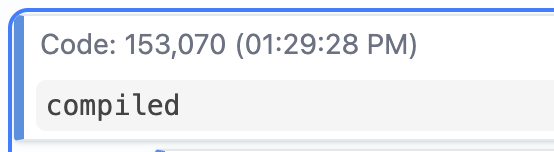


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Different tokenizers give different counts — that's expected. `n_tokens` uses OpenAI's `cl100k_base` (GPT-4 tokenizer), while solveit counts using Claude's tokenizer. They encode text differently, so numbers won't match.

Either way, ~153K tokens is well under Claude Desktop's file limits (typically ~200K+). The compiled JSON is ready to go.

<details class='token-usage-details' markdown='1'><summary>$0.0238</summary>

`total=139,193 | in=138,833 | out=360 | cached=18.7% | reasoning=276 | searches=0 | $0.0238`

</details>


Can we do it also now but for the "outs" tags in "mappings"?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Let's first check the structure of an `outs` tag:

```python
ex['mappings']['outs'][0]
```

<details class='token-usage-details' markdown='1'><summary>$0.0004</summary>

`total=28,489 | in=28,404 | out=85 | cached=93.7% | reasoning=58 | searches=0 | $0.0004`

</details>


In [ ]:
ex['mappings']['outs'][0]

{'theme_id': '1a31',
 'theme_title': 'Guidelines on data and information collection, sharing and management are in place that adhere to data protection standards, principles of confidentiality and a defined purpose, to protect the individuals and groups providing information from harm.',
 'relevance_score': 0.45,
 'reasoning': "The excerpts reviewed contain some content tangentially relevant to this Output. The NTMI project developed protocols for data collection and information sharing among migration authorities in the Northern Triangle, and the report mentions the establishment of a 'Boleta única de Registro' (unified registration form) and data management systems. Data protection and confidentiality principles are not explicitly discussed in the excerpts as a primary analytical focus, though the broader data management infrastructure work touches on this theme. The conclusions mention reducing 're-victimization' of returnees through information sharing, which implies some sensitivi

Same principle

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Same structure — let's write a combined version that picks both `gcms` and `outs`:

```python
def extract_tags(rpt, key='gcms'):
    "Extract relevant tags from a report, adding classification"
    tags = L(rpt.get('mappings', {}).get(key, []))
    return list(tags.map(lambda o: {**o, 'relevance_class': rel_class(o['relevance_score'])}).filter(lambda o: o['relevance_class']))

def build_rpt(rpt):
    "Build a report record with metadata and GCM + Outputs tags"
    m = rpt['meta']
    gcms, outs = extract_tags(rpt, 'gcms'), extract_tags(rpt, 'outs')
    if not gcms and not outs: return None
    return dict(id=rpt['id'], report_url=rpt['report_url'], title=m['Title'], year=m.get('Year',''),
        author=m.get('Author',''), donor=m.get('Donor',''), languages=m.get('Languages',''),
        n_pages=m.get('Number of Pages Excluding annexes'), project_code=m.get('Project Code',''),
        countries=m.get('Countries Covered',[]), regions=m.get('Regions Covered',[]),
        eval_scope=m.get('Type of Evaluation Scope',''), eval_timing=m.get('Type of Evaluation Timing',''),
        evaluator=m.get('Type of Evaluator',''), eval_level=m.get('Level of Evaluation',''),
        selected_headings=rpt.get('selected_headings',[]), gcm_tags=gcms, output_tags=outs)

compiled = list(L(o for o in (build_rpt(r) for r in rpts) if o is not None))
len(compiled)
```

Then check size and token count:

```python
Path('compiled_tags.json').write_text(json.dumps(compiled, indent=2, ensure_ascii=False))
p = Path('compiled_tags.json')
p.stat().st_size / 1e6, n_tokens(json.dumps(compiled, ensure_ascii=False))
```

<details class='token-usage-details' markdown='1'><summary>$0.0006</summary>

`total=29,309 | in=28,805 | out=504 | cached=92.9% | reasoning=57 | searches=0 | $0.0006`

</details>


In [ ]:
def extract_tags(rpt, key='gcms'):
    "Extract relevant tags from a report, adding classification"
    tags = L(rpt.get('mappings', {}).get(key, []))
    return list(tags.map(lambda o: {**o, 'relevance_class': rel_class(o['relevance_score'])}).filter(lambda o: o['relevance_class']))

def build_rpt(rpt):
    "Build a report record with metadata and GCM + Outputs tags"
    m = rpt['meta']
    gcms, outs = extract_tags(rpt, 'gcms'), extract_tags(rpt, 'outs')
    if not gcms and not outs: return None
    return dict(id=rpt['id'], report_url=rpt['report_url'], title=m['Title'], year=m.get('Year',''),
        author=m.get('Author',''), donor=m.get('Donor',''), languages=m.get('Languages',''),
        n_pages=m.get('Number of Pages Excluding annexes'), project_code=m.get('Project Code',''),
        countries=m.get('Countries Covered',[]), regions=m.get('Regions Covered',[]),
        eval_scope=m.get('Type of Evaluation Scope',''), eval_timing=m.get('Type of Evaluation Timing',''),
        evaluator=m.get('Type of Evaluator',''), eval_level=m.get('Level of Evaluation',''),
        selected_headings=rpt.get('selected_headings',[]), gcm_tags=gcms, output_tags=outs)

compiled = list(L(o for o in (build_rpt(r) for r in rpts) if o is not None))
len(compiled)

459

In [ ]:
Path('compiled_tags_srf_outs.json').write_text(json.dumps(compiled, indent=2, ensure_ascii=False))
p = Path('compiled_tags_srf_outs.json')
p.stat().st_size / 1e6, n_tokens(json.dumps(compiled, ensure_ascii=False))

(4.234503, 806557)

Wait I only want it either for gcms or outs. No need to have them both in same file it's just bloating the file, there is no use case where both should be analyzed jointly

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Makes sense. Let's just generate the `outs` version separately:

```python
def build_rpt_outs(rpt):
    "Build a report record with metadata and Outputs tags only"
    m = rpt['meta']
    outs = extract_tags(rpt, 'outs')
    if not outs: return None
    return dict(id=rpt['id'], report_url=rpt['report_url'], title=m['Title'], year=m.get('Year',''),
        author=m.get('Author',''), donor=m.get('Donor',''), languages=m.get('Languages',''),
        n_pages=m.get('Number of Pages Excluding annexes'), project_code=m.get('Project Code',''),
        countries=m.get('Countries Covered',[]), regions=m.get('Regions Covered',[]),
        eval_scope=m.get('Type of Evaluation Scope',''), eval_timing=m.get('Type of Evaluation Timing',''),
        evaluator=m.get('Type of Evaluator',''), eval_level=m.get('Level of Evaluation',''),
        selected_headings=rpt.get('selected_headings',[]), output_tags=outs)

compiled_outs = list(L(o for o in (build_rpt_outs(r) for r in rpts) if o is not None))
len(compiled_outs), n_tokens(json.dumps(compiled_outs, ensure_ascii=False))
```

<details class='token-usage-details' markdown='1'><summary>$0.0005</summary>

`total=30,196 | in=29,873 | out=323 | cached=94.3% | reasoning=35 | searches=0 | $0.0005`

</details>


In [ ]:
def build_rpt_outs(rpt):
    "Build a report record with metadata and Outputs tags only"
    m = rpt['meta']
    outs = extract_tags(rpt, 'outs')
    if not outs: return None
    return dict(id=rpt['id'], report_url=rpt['report_url'], title=m['Title'], year=m.get('Year',''),
        author=m.get('Author',''), donor=m.get('Donor',''), languages=m.get('Languages',''),
        n_pages=m.get('Number of Pages Excluding annexes'), project_code=m.get('Project Code',''),
        countries=m.get('Countries Covered',[]), regions=m.get('Regions Covered',[]),
        eval_scope=m.get('Type of Evaluation Scope',''), eval_timing=m.get('Type of Evaluation Timing',''),
        evaluator=m.get('Type of Evaluator',''), eval_level=m.get('Level of Evaluation',''),
        selected_headings=rpt.get('selected_headings',[]), output_tags=outs)

compiled_outs = list(L(o for o in (build_rpt_outs(r) for r in rpts) if o is not None))
len(compiled_outs), n_tokens(json.dumps(compiled_outs, ensure_ascii=False))

(444, 524265)

then let's write it?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
Path('compiled_outs.json').write_text(json.dumps(compiled_outs, indent=2, ensure_ascii=False))
p = Path('compiled_outs.json')
p.stat().st_size / 1e6
```

<details class='token-usage-details' markdown='1'><summary>$0.0005</summary>

`total=30,619 | in=30,547 | out=72 | cached=93.4% | reasoning=17 | searches=0 | $0.0005`

</details>


In [ ]:
Path('compiled_outs.json').write_text(json.dumps(compiled_outs, indent=2, ensure_ascii=False))
p = Path('compiled_outs.json')
p.stat().st_size / 1e6

2.697138

Ok let's do the same for enbs and ccps (separately)

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
def build_rpt_enbs(rpt):
    "Build a report record with metadata and ENBS tags only"
    m = rpt['meta']
    enbs = extract_tags(rpt, 'enbs')
    if not enbs: return None
    return dict(id=rpt['id'], report_url=rpt['report_url'], title=m['Title'], year=m.get('Year',''),
        author=m.get('Author',''), donor=m.get('Donor',''), languages=m.get('Languages',''),
        n_pages=m.get('Number of Pages Excluding annexes'), project_code=m.get('Project Code',''),
        countries=m.get('Countries Covered',[]), regions=m.get('Regions Covered',[]),
        eval_scope=m.get('Type of Evaluation Scope',''), eval_timing=m.get('Type of Evaluation Timing',''),
        evaluator=m.get('Type of Evaluator',''), eval_level=m.get('Level of Evaluation',''),
        selected_headings=rpt.get('selected_headings',[]), enb_tags=enbs)

def build_rpt_ccps(rpt):
    "Build a report record with metadata and CCPS tags only"
    m = rpt['meta']
    ccps = extract_tags(rpt, 'ccps')
    if not ccps: return None
    return dict(id=rpt['id'], report_url=rpt['report_url'], title=m['Title'], year=m.get('Year',''),
        author=m.get('Author',''), donor=m.get('Donor',''), languages=m.get('Languages',''),
        n_pages=m.get('Number of Pages Excluding annexes'), project_code=m.get('Project Code',''),
        countries=m.get('Countries Covered',[]), regions=m.get('Regions Covered',[]),
        eval_scope=m.get('Type of Evaluation Scope',''), eval_timing=m.get('Type of Evaluation Timing',''),
        evaluator=m.get('Type of Evaluator',''), eval_level=m.get('Level of Evaluation',''),
        selected_headings=rpt.get('selected_headings',[]), ccp_tags=ccps)

compiled_enbs = list(L(o for o in (build_rpt_enbs(r) for r in rpts) if o is not None))
compiled_ccps = list(L(o for o in (build_rpt_ccps(r) for r in rpts) if o is not None))
len(compiled_enbs), len(compiled_ccps), n_tokens(json.dumps(compiled_enbs, ensure_ascii=False)), n_tokens(json.dumps(compiled_ccps, ensure_ascii=False))
```

<details class='token-usage-details' markdown='1'><summary>$0.0005</summary>

`total=31,380 | in=30,775 | out=605 | cached=96.1% | reasoning=50 | searches=0 | $0.0005`

</details>


In [ ]:
def build_rpt_enbs(rpt):
    "Build a report record with metadata and ENBS tags only"
    m = rpt['meta']
    enbs = extract_tags(rpt, 'enbs')
    if not enbs: return None
    return dict(id=rpt['id'], report_url=rpt['report_url'], title=m['Title'], year=m.get('Year',''),
        author=m.get('Author',''), donor=m.get('Donor',''), languages=m.get('Languages',''),
        n_pages=m.get('Number of Pages Excluding annexes'), project_code=m.get('Project Code',''),
        countries=m.get('Countries Covered',[]), regions=m.get('Regions Covered',[]),
        eval_scope=m.get('Type of Evaluation Scope',''), eval_timing=m.get('Type of Evaluation Timing',''),
        evaluator=m.get('Type of Evaluator',''), eval_level=m.get('Level of Evaluation',''),
        selected_headings=rpt.get('selected_headings',[]), enb_tags=enbs)

def build_rpt_ccps(rpt):
    "Build a report record with metadata and CCPS tags only"
    m = rpt['meta']
    ccps = extract_tags(rpt, 'ccps')
    if not ccps: return None
    return dict(id=rpt['id'], report_url=rpt['report_url'], title=m['Title'], year=m.get('Year',''),
        author=m.get('Author',''), donor=m.get('Donor',''), languages=m.get('Languages',''),
        n_pages=m.get('Number of Pages Excluding annexes'), project_code=m.get('Project Code',''),
        countries=m.get('Countries Covered',[]), regions=m.get('Regions Covered',[]),
        eval_scope=m.get('Type of Evaluation Scope',''), eval_timing=m.get('Type of Evaluation Timing',''),
        evaluator=m.get('Type of Evaluator',''), eval_level=m.get('Level of Evaluation',''),
        selected_headings=rpt.get('selected_headings',[]), ccp_tags=ccps)

compiled_enbs = list(L(o for o in (build_rpt_enbs(r) for r in rpts) if o is not None))
compiled_ccps = list(L(o for o in (build_rpt_ccps(r) for r in rpts) if o is not None))
len(compiled_enbs), len(compiled_ccps), n_tokens(json.dumps(compiled_enbs, ensure_ascii=False)), n_tokens(json.dumps(compiled_ccps, ensure_ascii=False))

(403, 376, 319694, 262614)

And save it with proper names

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
Path('compiled_enbs.json').write_text(json.dumps(compiled_enbs, indent=2, ensure_ascii=False))
Path('compiled_ccps.json').write_text(json.dumps(compiled_ccps, indent=2, ensure_ascii=False))
```

Check sizes:

```python
for f in ['compiled_gcm.json','compiled_outs.json','compiled_enbs.json','compiled_ccps.json']:
    p = Path(f)
    print(f"{f}: {p.stat().st_size/1e6:.2f} MB, {n_tokens(json.dumps(compiled, ensure_ascii=False) if 'gcm' in f else None)} tokens")
```

Actually let's just list them properly:

```python
for f in ['compiled_gcm.json','compiled_outs.json','compiled_enbs.json','compiled_ccps.json']:
    p = Path(f)
    print(f"{f}: {p.stat().st_size/1e6:.2f} MB")
```



```python
for f in ['compiled_gcm.json','compiled_outs.json','compiled_enbs.json','compiled_ccps.json']:
    p = Path(f)
    print(f"{f}: {p.stat().st_size/1e6:.2f} MB")
```

<details class='token-usage-details' markdown='1'><summary>$0.0005</summary>

`total=32,316 | in=32,005 | out=311 | cached=94.8% | reasoning=18 | searches=0 | $0.0005`

</details>


In [ ]:
Path('compiled_enbs.json').write_text(json.dumps(compiled_enbs, indent=2, ensure_ascii=False))
Path('compiled_ccps.json').write_text(json.dumps(compiled_ccps, indent=2, ensure_ascii=False))

1246983

In [ ]:
for f in ['compiled_gcm.json','compiled_outs.json','compiled_enbs.json','compiled_ccps.json']:
    p = Path(f)
    print(f"{f}: {p.stat().st_size/1e6:.2f} MB, {n_tokens(json.dumps(compiled, ensure_ascii=False) if 'gcm' in f else None)} tokens")

compiled_gcm.json: 2.03 MB, 806557 tokens


TypeError: expected string or buffer

Local files looks ok but why the error above?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

The error is from my sloppy one-liner — when `'gcm' not in f`, the ternary gives `None` to `n_tokens()`. Let's just print cleanly:

```python
for f in ['compiled_gcm.json','compiled_outs.json','compiled_enbs.json','compiled_ccps.json']:
    p = Path(f)
    print(f"{f}: {p.stat().st_size/1e6:.2f} MB")
```

And for token counts, we can read each file back:

```python
for f in ['compiled_gcm.json','compiled_outs.json','compiled_enbs.json','compiled_ccps.json']:
    c = json.loads(Path(f).read_text())
    print(f"{f}: {n_tokens(json.dumps(c, ensure_ascii=False))} tokens")
```

<details class='token-usage-details' markdown='1'><summary>$0.0006</summary>

`total=33,190 | in=32,915 | out=275 | cached=92.9% | reasoning=88 | searches=0 | $0.0006`

</details>


In [ ]:
for f in ['compiled_gcm.json','compiled_outs.json','compiled_enbs.json','compiled_ccps.json']:
    p = Path(f)
    print(f"{f}: {p.stat().st_size/1e6:.2f} MB")

compiled_gcm.json: 2.03 MB
compiled_outs.json: 2.70 MB
compiled_enbs.json: 1.56 MB
compiled_ccps.json: 1.25 MB


In [ ]:
for f in ['compiled_gcm.json','compiled_outs.json','compiled_enbs.json','compiled_ccps.json']:
    p = Path(f)
    print(f"{f}: {p.stat().st_size/1e6:.2f} MB")

compiled_gcm.json: 2.03 MB
compiled_outs.json: 2.70 MB
compiled_enbs.json: 1.56 MB
compiled_ccps.json: 1.25 MB


Ok looks good right?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Looks good! Four clean, focused files — each well under Claude Desktop's limits:

| File | Size | Reports |
|------|------|---------|
| `compiled_gcm.json` | 2.0 MB | 458 |
| `compiled_outs.json` | 2.7 MB | 444 |
| `compiled_enbs.json` | 1.6 MB | 403 |
| `compiled_ccps.json` | 1.2 MB | 376 |

You can upload each one to a separate Claude project (one per framework), or merge a couple if needed. Ready to go.

<details class='token-usage-details' markdown='1'><summary>$0.0005</summary>

`total=33,724 | in=33,473 | out=251 | cached=94.8% | reasoning=120 | searches=0 | $0.0005`

</details>
